# TD1 — Embeddings: from words to meaning

**~1h · the first brick of the PIM assistant you build across TD1–TD5.**

The big question: *how can a machine represent the **meaning** of a product, so that two similar products are "close" even when they don't share any words?*

By the end of this lab you can:
1. explain **why** we need embeddings (and why plain word-matching fails);
2. measure semantic proximity with **cosine similarity** and build a small **semantic search**;
3. **read** an embedding space in 2D;
4. treat *"which model?"* as an **engineering trade-off**.

**How to work:** run the notebook top to bottom; complete the `# TODO` cells; and **ask Claude Code first** whenever you're stuck. 🚀

## 1. Setup

In [1]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

%matplotlib inline

# Shared PIM catalog — the same dataset used in TD2, TD3, TD4.
df = pd.read_csv("../data/products.csv")

# The text we embed for each product: its name plus the long description.
df["text"] = df["name"] + " — " + df["long_description"]

print(f"Loaded {len(df)} products across {df['category'].nunique()} categories.")
df[["sku", "name", "brand", "category", "price"]].head(3)

Loaded 198 products across 22 categories.


,sku,name,brand,category,price
0,SKU-0001,Sony WH-1000XM5,Sony,Headphones,379.0
1,SKU-0002,Bose QuietComfort Ultra,Bose,Headphones,449.0
2,SKU-0003,Sennheiser Momentum 4 Wireless,Sennheiser,Headphones,299.0


## 2. Why not just match words?

Before embeddings, the simplest way to compare two texts is to look at the **words they share**. This is the spirit of **one-hot** / **bag-of-words** encoding from the lecture: each word becomes its own independent dimension, and a text is just the set (or count) of words it contains.

The problem: this representation sees only **surface tokens**, never **meaning**. Let's make that concrete with a tiny *lexical* similarity (Jaccard overlap on word sets).

In [2]:
def lexical_similarity(a, b):
    """Jaccard overlap on lowercased word sets: do two strings share words?"""
    wa, wb = set(a.lower().split()), set(b.lower().split())
    return len(wa & wb) / len(wa | wb)

same_meaning = ("wireless noise-cancelling over-ear headphones",
                "premium bluetooth headset with active noise cancellation")
shared_word = ("apple watch", "apple pie recipe")

print("Same meaning, few shared words:")
print(f"  lexical similarity = {lexical_similarity(*same_meaning):.2f}")
print("Different meaning, a shared word:")
print(f"  lexical similarity = {lexical_similarity(*shared_word):.2f}")

Same meaning, few shared words:
  lexical similarity = 0.00
Different meaning, a shared word:
  lexical similarity = 0.25


**Question.** Why is lexical (word-overlap) similarity a poor measure of product similarity? Relate it to the limits of one-hot / bag-of-words encoding from the lecture.

**Your answer** — write it yourself. You may use AI to help you think it through, but the written answer must be in your own words.

Lexical similarity is not always the best way to compare two texts because it only looks at the words they have in common. In practice, two product descriptions can mean almost the same thing but use different wording, which leads to a low similarity score. At the same time, two texts can contain many of the same words while referring to completely different things. This shows one of the main limitations of one-hot and bag-of-words models. Since these approaches consider each word separately, they do not capture the relationships between words or the actual meaning of the text.

## 3. From text to vector (embeddings)

An **embedding model** maps any piece of text to a fixed-length vector of numbers (e.g. 384 values) that is meant to capture its **meaning**: texts with similar meaning land at nearby points in that high-dimensional space. We'll use [`sentence-transformers`](https://www.sbert.net/), which downloads a small pretrained model and runs it **locally** — no API, no cost.

In [3]:
# Small, fast embedding model (downloads on first run; cached afterwards).
model = SentenceTransformer("all-MiniLM-L6-v2")

vec = model.encode("Wireless noise-cancelling headphones")
print(f"Embedding dimension: {vec.shape[0]}")
print(f"First 5 values: {vec[:5]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding dimension: 384
First 5 values: [-0.05025906  0.06580368  0.00443387  0.03372138 -0.04303835]


In [4]:
# TODO: encode BOTH strings of `same_meaning` in one call (pass them as a list).
#       Store the (2, 384) array in `pair_emb`.
pair_emb = model.encode(list(same_meaning))

print(pair_emb.shape if pair_emb is not None else "Not implemented yet.")

(2, 384)


## 4. Cosine similarity & nearest neighbours

Now we have vectors — how do we measure how *close in meaning* two of them are? The standard tool is **cosine similarity**: it's the cosine of the angle between the two vectors, so it cares about their **direction**, not their length.

$$\cos(\theta) = \frac{a \cdot b}{\lVert a \rVert \, \lVert b \rVert}$$

Intuition: **1** = same direction (same meaning), **0** = unrelated (perpendicular), **−1** = opposite. This is the centerpiece of the whole lab.

In [8]:
def cosine_similarity(a, b):
    """cos(theta) = (a . b) / (||a|| * ||b||). ~1 = same direction (meaning), ~0 = unrelated."""
    # TODO: implement with numpy (np.dot, np.linalg.norm). Return a float.
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

# Self-check once implemented:
# print(cosine_similarity(np.array([1., 0]), np.array([1., 0])))  # -> 1.0
# print(cosine_similarity(np.array([1., 0]), np.array([0., 1])))  # -> 0.0

In [9]:
emb_same = model.encode(list(same_meaning))
emb_shared = model.encode(list(shared_word))

print("Embeddings — same meaning, few shared words :",
      round(cosine_similarity(emb_same[0], emb_same[1]), 2))
print("Embeddings — shared word, different meaning :",
      round(cosine_similarity(emb_shared[0], emb_shared[1]), 2))

Embeddings — same meaning, few shared words : 0.72
Embeddings — shared word, different meaning : 0.26


Notice how the **verdict flips** compared to the lexical score: the two paraphrased headphones are now *close*, and "apple watch" / "apple pie" are *far apart*. Meaning has become geometry.

Now let's scale this up to the whole catalog.

In [10]:
catalog_emb = model.encode(df["text"].tolist())
print("Catalog embeddings:", catalog_emb.shape)  # (198, 384)

Catalog embeddings: (198, 384)


In [11]:
def top_k_similar(query, catalog_emb, model, k=5):
    """Return the k catalog products most similar to `query`, as a DataFrame with a 'similarity' column.
    Steps: (1) embed the query; (2) cosine-score it against every row of catalog_emb;
           (3) take the k highest-scoring indices; (4) return df.iloc[indices] + a 'similarity' column."""
    # TODO: implement
    query_emb = model.encode(query)

    scores = np.array([
        cosine_similarity(query_emb, emb)
        for emb in catalog_emb
    ])

    top_idx = np.argsort(scores)[-k:][::-1]
    
    result = df.iloc[top_idx].copy()
    result["similarity"] = scores[top_idx]

    return result

# top_k_similar("something to listen to music on the train", catalog_emb, model)[["name", "category", "similarity"]]

In [12]:
queries = [
    "a gift for someone who loves cooking",
    "portable speaker for the beach",
    "I want to read a science-fiction story",
]
for q in queries:
    print(f"\nQuery: {q!r}")
    print(top_k_similar(q, catalog_emb, model, k=3)[["name", "category", "similarity"]].to_string(index=False))


Query: 'a gift for someone who loves cooking'
                                       name      category  similarity
Tefal Jamie Oliver Quick & Easy 5-Piece Set Cookware Sets    0.336581
          Ninja Foodi ZeroStick 5-Piece Set Cookware Sets    0.320400
       Tefal Ingenio Expertise 10-Piece Set Cookware Sets    0.309757

Query: 'portable speaker for the beach'
                   name           category  similarity
    Bose SoundLink Flex Bluetooth Speakers    0.536110
Tribit StormBox Micro 2 Bluetooth Speakers    0.432882
        JBL Tour One M2         Headphones    0.385503

Query: 'I want to read a science-fiction story'
                name category  similarity
   Project Hail Mary    Books    0.352839
The Midnight Library    Books    0.342060
     Le Petit Prince    Books    0.282375


You just built a tiny **vector search** — a query goes in, the most semantically similar products come out. In **TD3** you'll replace this numpy loop with **ChromaDB**, a real vector database; that's the *retrieval* half of RAG.

**Question.** Pick one vague query of your own (run it with `top_k_similar`). Are the neighbours sensible? Where does it struggle, and why?

**Your answer** — write it yourself (AI may help you think, but the answer must be your own). Paste your query, then a one-paragraph observation.

Query: "a gift for someone who loves cooking"

The model returns items related to cooking or kitchen products, which is generally sensible. However, it may sometimes retrieve items that are only loosely related to cooking because the word “gift” is very broad and can apply to many categories. This shows that embeddings capture overall semantic themes but can still be influenced by general-purpose words.

## 5. Seeing the whole space (2D)

Our vectors live in 384 dimensions — we can't see that directly. **PCA** (Principal Component Analysis) projects them down to the 2 directions of greatest variance, so we can *plot* the catalog and look at its structure. Some information is lost in the projection, but the **big clusters survive** — and that's exactly what we want to inspect.

In [13]:
from sklearn.decomposition import PCA

# TODO: fit PCA(n_components=2) on `catalog_emb` and transform it to 2D.
#       Store the (198, 2) result in `coords_2d`.
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(catalog_emb)

print(coords_2d.shape if coords_2d is not None else "Not implemented yet.")

(198, 2)


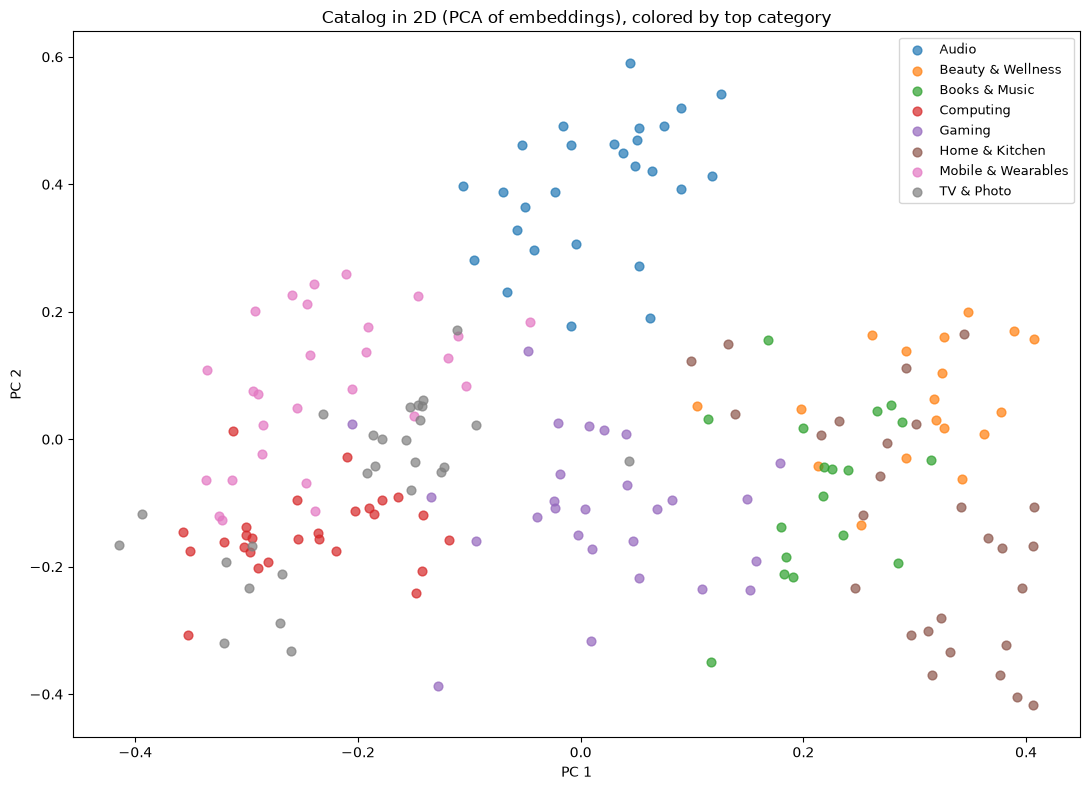

In [14]:
with open("../data/taxonomy.json") as f:
    taxo = json.load(f)
leaf_to_top = {sub["name"]: top["name"] for top in taxo["categories"] for sub in top["subcategories"]}
df["top_category"] = df["category"].map(leaf_to_top)

plt.figure(figsize=(11, 8))
for top in sorted(df["top_category"].unique()):
    mask = (df["top_category"] == top).values
    plt.scatter(coords_2d[mask, 0], coords_2d[mask, 1], label=top, alpha=0.7, s=40)
plt.legend(loc="best", fontsize=9)
plt.title("Catalog in 2D (PCA of embeddings), colored by top category")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

**Question.** Which categories form tight clusters? Which ones overlap? (Look in particular at *Headphones* vs *Wireless Earbuds*, and *Smartwatches* vs *Fitness Trackers*.) What does that predict about how hard categorization will be in TD2?

**Your answer** — write it yourself. You may use AI to help you think it through, but the written answer must be in your own words.

The PCA plot shows that the Audio (blue) and Computing (red) categories form compact, well-separated clusters. This suggests that a classification model should have little difficulty identifying products that belong to these categories. On the other hand, Beauty & Wellness (orange), Books & Music (green), and Home & Kitchen (brown) overlap considerably on the right side of the plot, making the boundaries between them much less distinct. At the subcategory level, Headphones and Wireless Earbuds are grouped very closely within the Audio cluster. While this makes it easy for the model to distinguish them from products in other categories, telling these two subcategories apart is likely to be more challenging. Similarly, Smartwatches and Fitness Trackers, which belong to Mobile & Wearables (pink), are spread across a much wider area and overlap with both Computing and TV & Photo. Overall, the visualization suggests that broad category classification in TD2 should perform well, whereas distinguishing between similar subcategories and separating the overlapping clusters on the right side of the plot is expected to be significantly more difficult.

## 6. Does it work across languages?

Real catalogs and real queries are often **multilingual**. The `all-MiniLM-L6-v2` model we've used so far was trained mostly on English, so a **French** query may land in the wrong neighbourhood. This is the practical motivation for **multilingual models** — and a concrete instance of the lecture's **low-resource languages** point. Let's probe it.

In [16]:
from sentence_transformers import SentenceTransformer

fr_query = "écouteurs sans fil pour le sport"

# TODO:
#  1. Load the multilingual model "paraphrase-multilingual-MiniLM-L12-v2" as `model_multi`.
model_multi = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
#  2. Re-embed the catalog with it -> `catalog_emb_multi`.
catalog_emb_multi = model_multi.encode(df["text"].tolist())
#  3. Top-3 for `fr_query` with the multilingual model (model_multi + catalog_emb_multi).
#  4. Top-3 for the SAME `fr_query` with the English-only model (model + catalog_emb).
def top_k(query, emb, model, k=3):
    q_emb = model.encode(query)
    scores = np.array([cosine_similarity(q_emb, e) for e in emb])
    idx = np.argsort(scores)[-k:][::-1]
    return df.iloc[idx][["name", "category"]].assign(similarity=scores[idx])
#  5. Print both result lists and compare.
print("\n--- Multilingual model ---")
print(top_k(fr_query, catalog_emb_multi, model_multi, k=3).to_string(index=False))

print("\n--- English-only model ---")
print(top_k(fr_query, catalog_emb, model, k=3).to_string(index=False))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


--- Multilingual model ---
                name           category  similarity
Ultimate Ears BOOM 4 Bluetooth Speakers    0.508923
     Sony WH-1000XM5         Headphones    0.499929
    Beats Studio Pro         Headphones    0.497242

--- English-only model ---
           name    category  similarity
EA Sports FC 25 Video Games    0.314305
Le Petit Prince       Books    0.221530
Forza Horizon 5 Video Games    0.214924


**Question.** Why does the multilingual model handle the French query better? Link this to *"low-resource languages"* and to when you'd reach for **fine-tuning** (from the lecture).

**Your answer** — write it yourself. You may use AI to help you think it through, but the written answer must be in your own words.

The multilingual model works better because it maps French and English texts into the same embedding space, so it can correctly match “écouteurs sans fil” with related English products. The English-only model treats French as a low-resource language, so it fails to build good semantic representations and returns irrelevant results. This shows that multilingual training improves cross-language understanding, and fine-tuning is useful when we still need better performance in a specific domain like product search or e-commerce.

## 7. Choosing an embedding model

There is no single "best" embedding model — it's an **engineering trade-off** along several axes: **dimensionality** (memory + storage in the vector DB), **encoding speed** (latency / cost at scale), **semantic quality**, and **language coverage**. The cell below *measures* three candidates so you can compare them on our own catalog. (`category_consistency` is a quick quality proxy: for a sample of products, is the nearest *other* product in the same leaf category? Higher = the space separates categories better.)

In [17]:
def category_consistency(embs, sample=60, seed=0):
    """Quality proxy: for a sample of products, is the nearest *other* product in the same leaf
    category? Higher = the space separates categories better."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(df), size=min(sample, len(df)), replace=False)
    norm = embs / np.linalg.norm(embs, axis=1, keepdims=True)
    hits = 0
    for i in idx:
        sims = norm @ norm[i]
        sims[i] = -1.0
        nn = int(np.argmax(sims))
        hits += int(df.iloc[nn]["category"] == df.iloc[i]["category"])
    return hits / len(idx)

candidates = ["all-MiniLM-L6-v2", "all-mpnet-base-v2", "paraphrase-multilingual-MiniLM-L12-v2"]
rows = []
for name in candidates:
    m = SentenceTransformer(name)
    t0 = time.perf_counter()
    embs = m.encode(df["text"].tolist())
    dt = time.perf_counter() - t0
    rows.append({"model": name, "dim": embs.shape[1],
                 "encode_time_s": round(dt, 2),
                 "category_consistency": round(category_consistency(embs), 2)})
measure_df = pd.DataFrame(rows)
measure_df

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,model,dim,encode_time_s,category_consistency
0,all-MiniLM-L6-v2,384,2.89,0.68
1,all-mpnet-base-v2,768,18.26,0.78
2,paraphrase-multilingual-MiniLM-L12-v2,384,5.53,0.68


**Question.** Read the table. Which model would you pick for this PIM, and why? In what situation would the **multilingual** model be the right default even if another scores higher here?

**Your answer** — write it yourself. You may use AI to help you think it through, but the written answer must be in your own words.

For this PIM, I would choose `all-mpnet-base-v2` because it has the highest category consistency (0.78), meaning it separates product categories more effectively and gives better semantic structure, even if it is much slower and has a larger embedding size. However, the multilingual model is the better default when the system must support users querying in multiple languages. Even if it performs slightly worse on this benchmark, it ensures good semantic matching for non-English queries, which is essential in a real product search system.

## 8. Wrap-up

What you take away from TD1:

- **Meaning becomes geometry.** An embedding turns text into a vector so that *similar meaning → nearby vector* — which is why word-overlap fails and cosine similarity works.
- The **`top_k_similar`** function you wrote *is* the **retrieval engine** behind RAG (TD3) and a **classification signal** (nearest-neighbour → TD2).
- The **2D view** shows where categories overlap — and that's exactly where TD2 categorization gets hard.
- **Model choice is a trade-off** (dimensionality, speed, quality, language coverage), not a search for one "best" model.

**Next:** **TD2** uses these vectors as features for a classifier and contrasts it with a zero-shot LLM; **TD3** turns your mini search into a real RAG with **ChromaDB**. ✅